In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.lines import lineStyles
from matplotlib.pyplot import annotate, legend
from sklearn import metrics

In [2]:
telecom_df=pd.read_csv("telecom_churn.csv")

In [3]:
telecom_df.head()

,state,account_length,area_code,phone_number,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,...,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,class
0,16,128,415,2845,0,1,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,35,107,415,2301,0,1,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,31,137,415,1616,0,0,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,35,84,408,2510,1,0,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,36,75,415,155,1,0,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


In [4]:
telecom_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   state                          5000 non-null   int64  
 1   account_length                 5000 non-null   int64  
 2   area_code                      5000 non-null   int64  
 3   phone_number                   5000 non-null   int64  
 4   international_plan             5000 non-null   int64  
 5   voice_mail_plan                5000 non-null   int64  
 6   number_vmail_messages          5000 non-null   int64  
 7   total_day_minutes              5000 non-null   float64
 8   total_day_calls                5000 non-null   int64  
 9   total_day_charge               5000 non-null   float64
 10  total_eve_minutes              5000 non-null   float64
 11  total_eve_calls                5000 non-null   int64  
 12  total_eve_charge               5000 non-null   f

In [31]:
telecom_df['class'].unique()

array([0, 1])

In [70]:
telecom_df.describe()

,state,account_length,area_code,phone_number,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,...,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,class
count,5000.00000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,25.99840,100.25860,436.911400,2499.500000,0.094600,0.264600,7.755200,180.288900,100.029400,30.649668,...,100.191000,17.054322,200.391620,99.919200,9.017732,10.261780,4.435200,2.771196,1.570400,0.141400
std,14.80348,39.69456,42.209182,1443.520003,0.292691,0.441164,13.546393,53.894699,19.831197,9.162069,...,19.826496,4.296843,50.527789,19.958686,2.273763,2.761396,2.456788,0.745514,1.306363,0.348469
min,0.00000,1.00000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,13.00000,73.00000,408.000000,1249.750000,0.000000,0.000000,0.000000,143.700000,87.000000,24.430000,...,87.000000,14.140000,166.900000,87.000000,7.510000,8.500000,3.000000,2.300000,1.000000,0.000000
50%,26.00000,100.00000,415.000000,2499.500000,0.000000,0.000000,0.000000,180.100000,100.000000,30.620000,...,100.000000,17.090000,200.400000,100.000000,9.020000,10.300000,4.000000,2.780000,1.000000,0.000000
75%,39.00000,127.00000,415.000000,3749.250000,0.000000,1.000000,17.000000,216.200000,113.000000,36.750000,...,114.000000,19.900000,234.700000,113.000000,10.560000,12.000000,6.000000,3.240000,2.000000,0.000000
max,50.00000,243.00000,510.000000,4999.000000,1.000000,1.000000,52.000000,351.500000,165.000000,59.760000,...,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000,1.000000


In [14]:
telecom_df.state.value_counts()

state
49    158
23    125
1     124
13    119
45    118
35    116
43    116
50    115
34    114
37    114
31    112
44    112
48    106
22    103
21    103
19    103
20    102
46    101
26     99
39     99
17     99
25     99
6      99
16     99
47     98
15     98
5      96
30     95
8      94
24     93
2      92
32     91
27     91
40     91
9      90
33     90
36     90
42     89
3      89
7      88
14     88
29     88
28     88
11     86
41     85
10     83
18     82
38     77
0      72
12     69
4      52
Name: count, dtype: int64

array([[<Axes: title={'center': 'state'}>,
        <Axes: title={'center': 'account_length'}>,
        <Axes: title={'center': 'area_code'}>,
        <Axes: title={'center': 'phone_number'}>,
        <Axes: title={'center': 'international_plan'}>],
       [<Axes: title={'center': 'voice_mail_plan'}>,
        <Axes: title={'center': 'number_vmail_messages'}>,
        <Axes: title={'center': 'total_day_minutes'}>,
        <Axes: title={'center': 'total_day_calls'}>,
        <Axes: title={'center': 'total_day_charge'}>],
       [<Axes: title={'center': 'total_eve_minutes'}>,
        <Axes: title={'center': 'total_eve_calls'}>,
        <Axes: title={'center': 'total_eve_charge'}>,
        <Axes: title={'center': 'total_night_minutes'}>,
        <Axes: title={'center': 'total_night_calls'}>],
       [<Axes: title={'center': 'total_night_charge'}>,
        <Axes: title={'center': 'total_intl_minutes'}>,
        <Axes: title={'center': 'total_intl_calls'}>,
        <Axes: title={'center': 'to

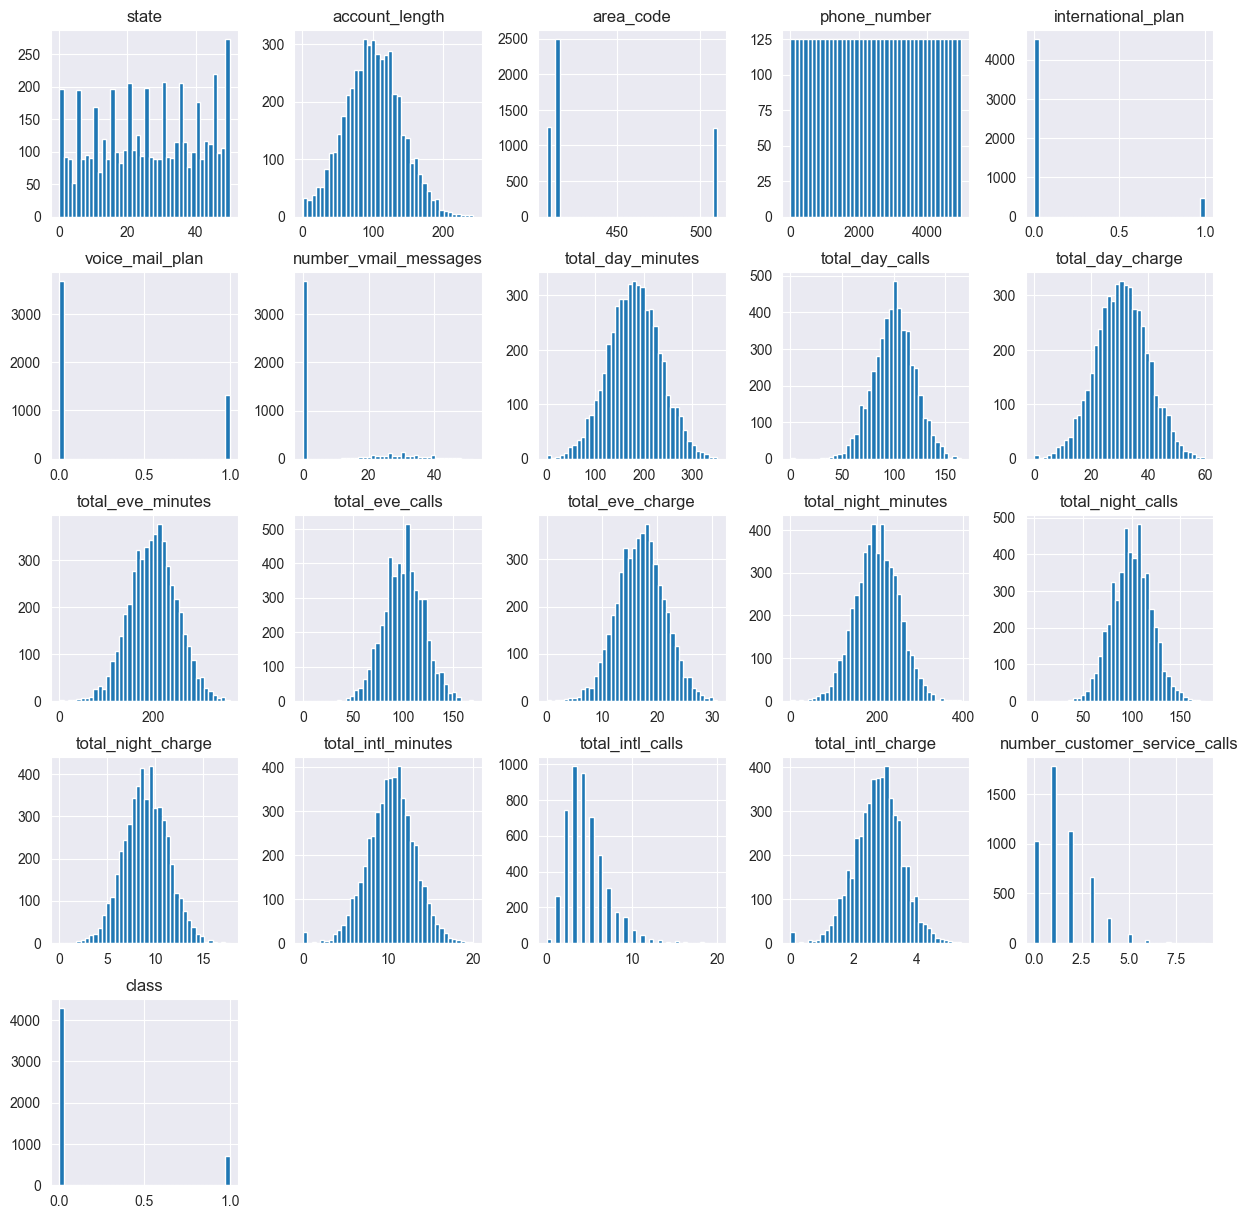

In [6]:
telecom_df.hist(figsize=(15,15),bins=40)

<Axes: ylabel='count'>

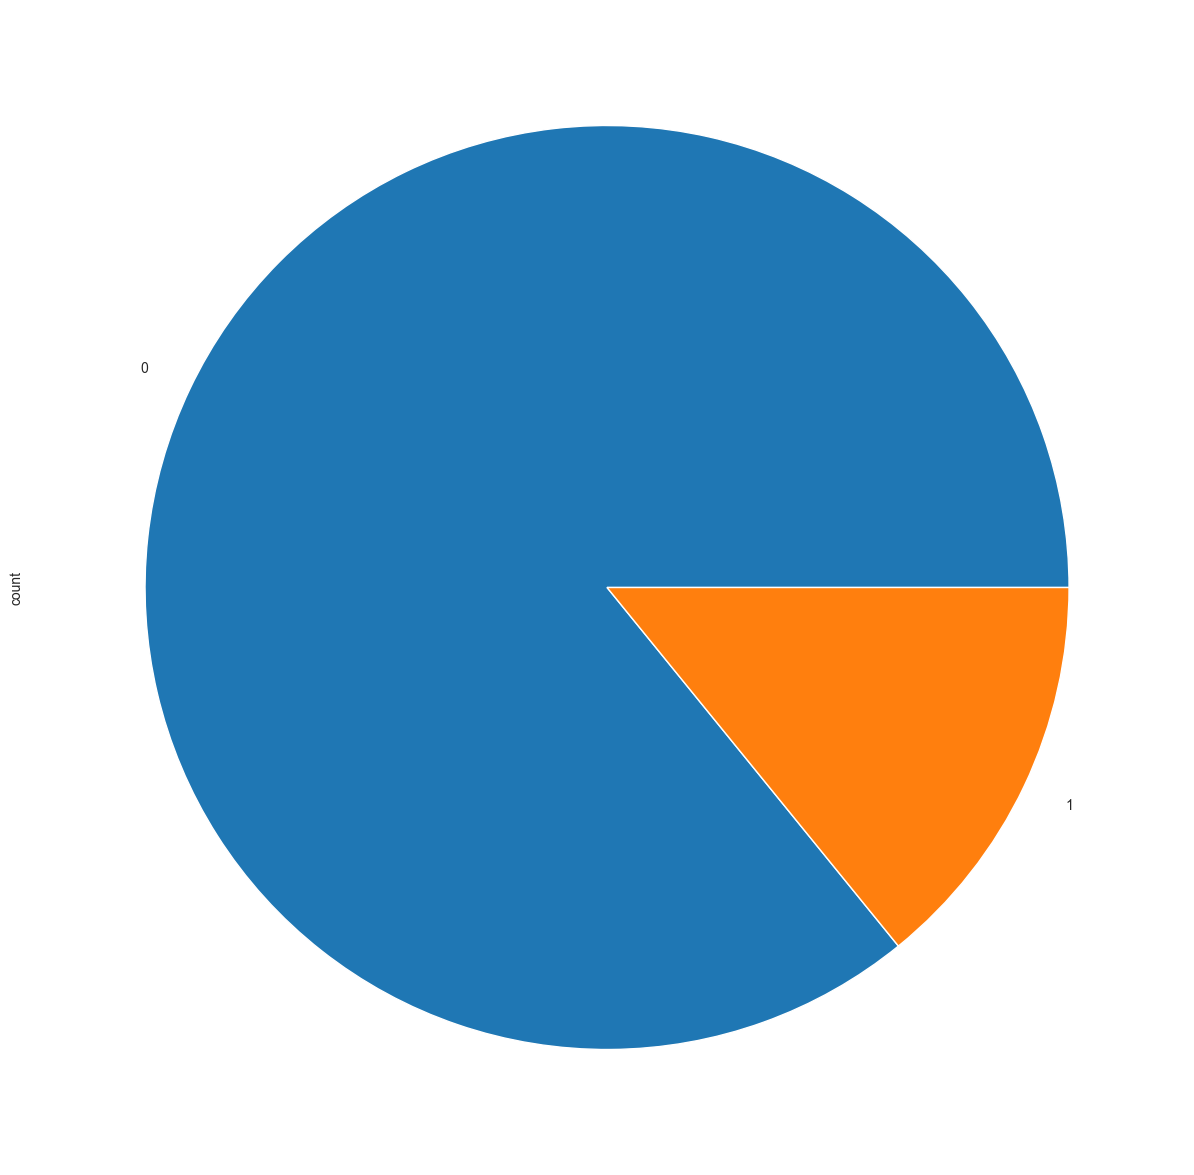

In [8]:
plt.figure(figsize=(15,15))
telecom_df['class'].value_counts().plot(kind='pie')

Text(0.5, 1.0, 'Correlation Heatmap')

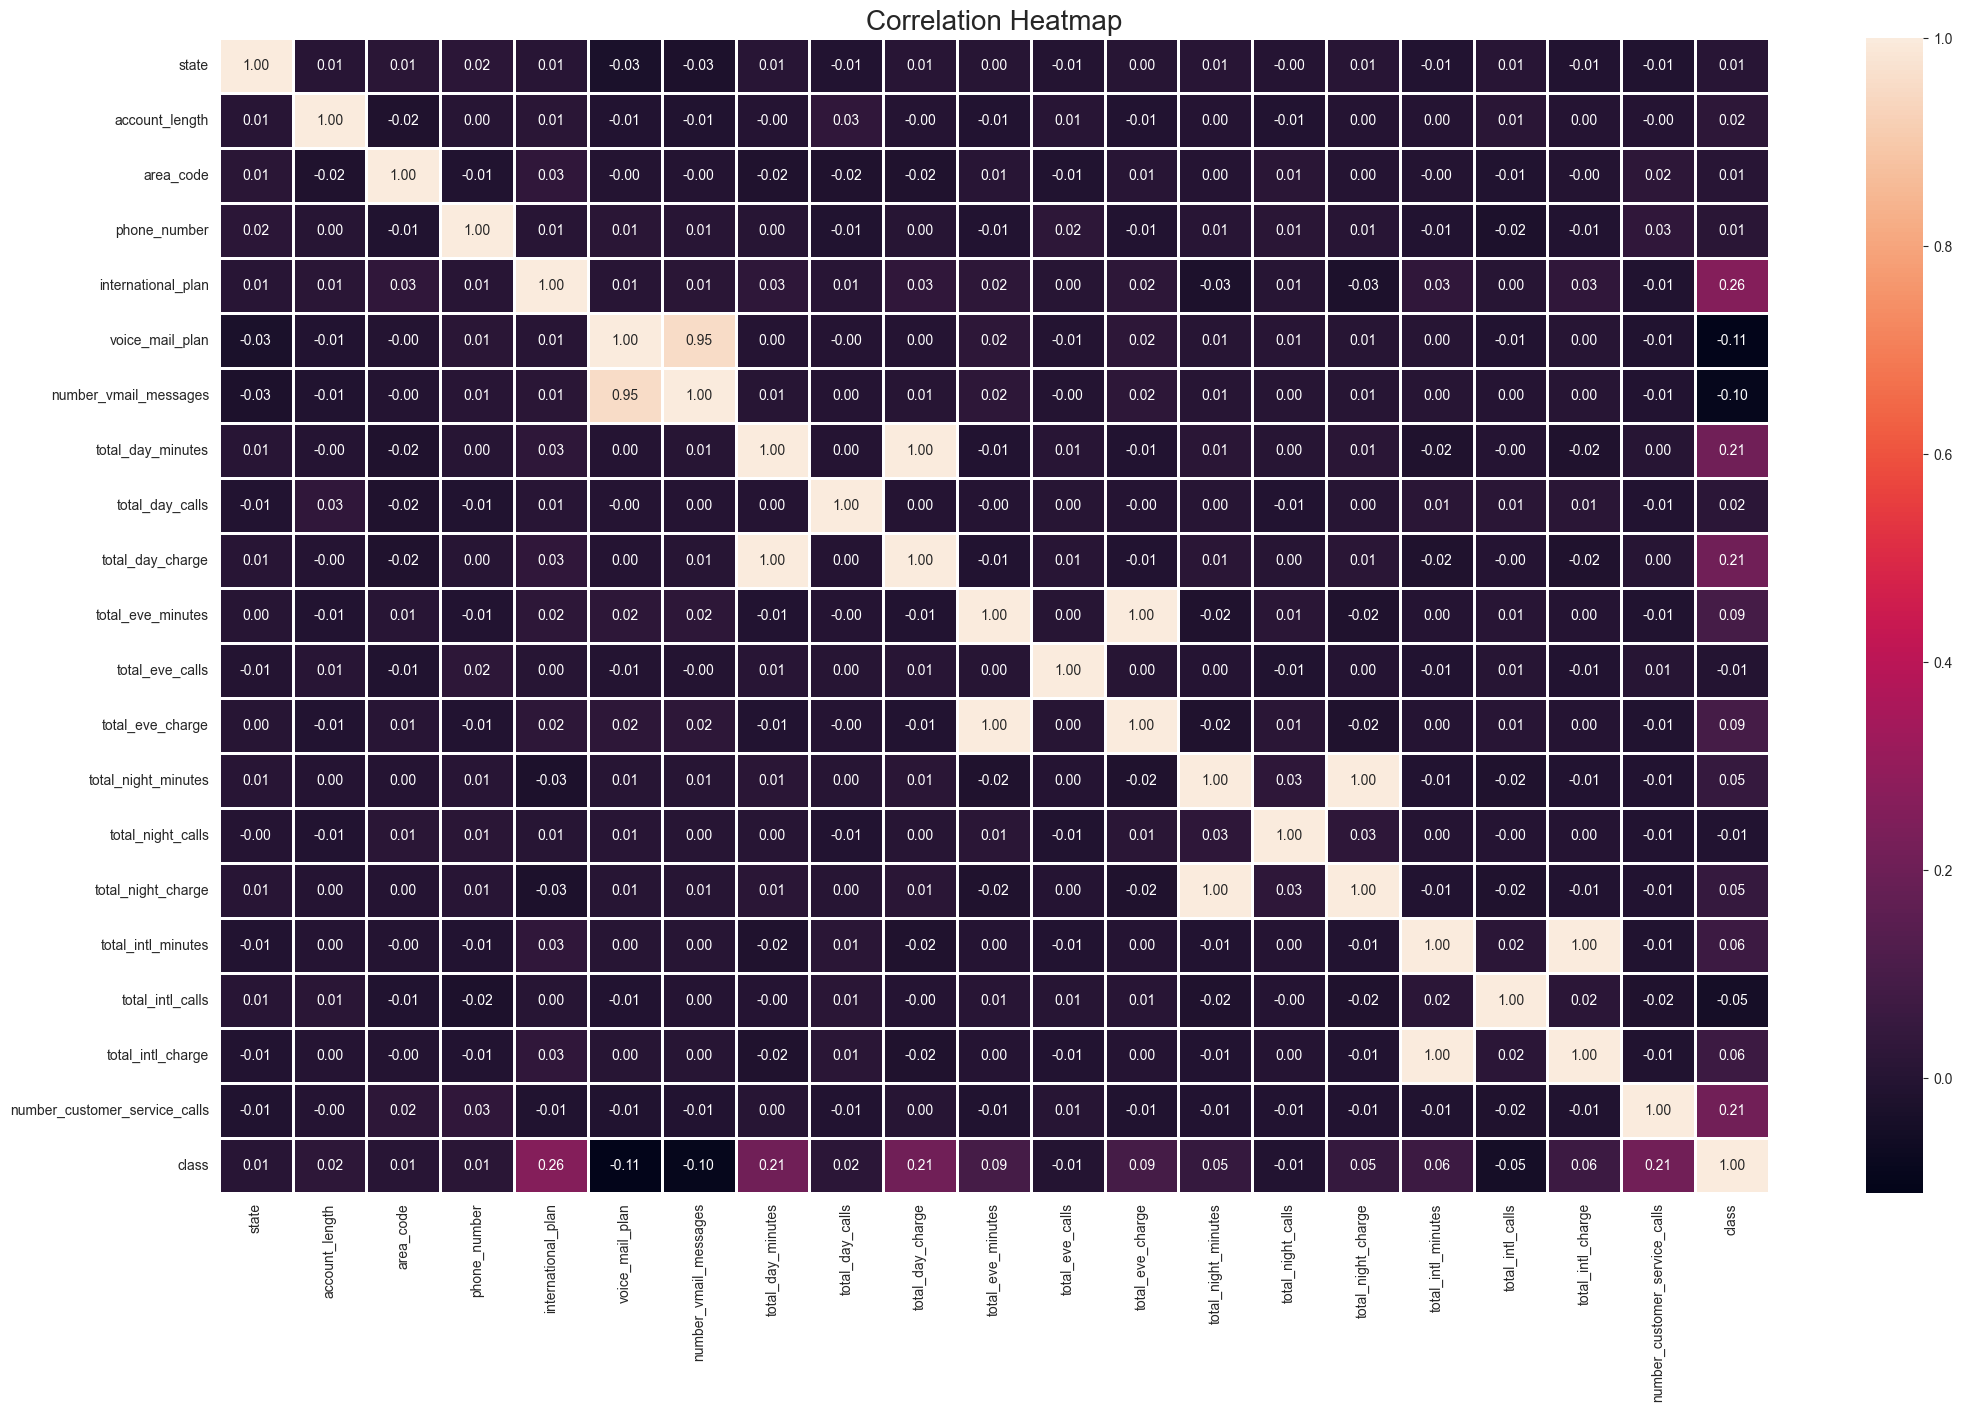

In [14]:
plt.figure(figsize=(25,15))
sns.heatmap(telecom_df.corr(),annot=True,linewidths=1,fmt=".2f")
plt.title('Correlation Heatmap',fontsize=20)

**disini kita membuat kde plot/plot kepadatan kernel untuk melihat sebaran data seperti histogram**

Text(0.5, 1.0, 'distribution of day charge by churn')

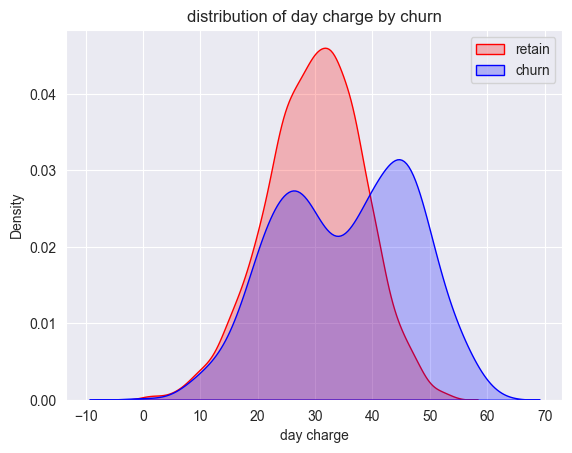

In [23]:
x=sns.kdeplot(telecom_df['total_day_charge'][telecom_df['class']==0],color='red',fill=True)
x=sns.kdeplot(telecom_df['total_day_charge'][telecom_df['class']==1],color='blue',fill=True)
x.legend(['retain','churn'])
x.set_xlabel('day charge')
x.set_title('distribution of day charge by churn')

Text(0.5, 1.0, 'distribution of eve charge by churn')

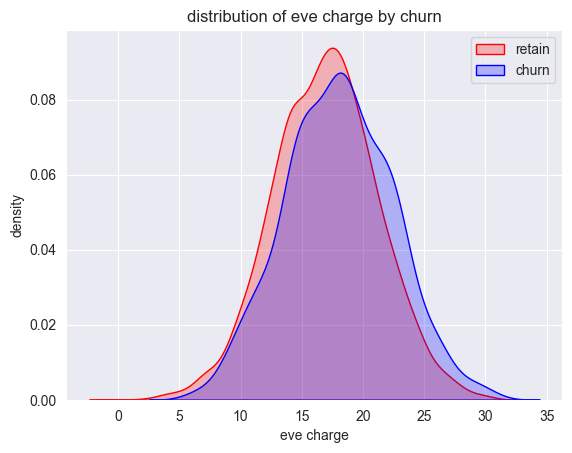

In [26]:
b=sns.kdeplot(telecom_df['total_eve_charge'][telecom_df['class']==0],color='red',fill=True)
b=sns.kdeplot(telecom_df['total_eve_charge'][telecom_df['class']==1],color='blue',fill=True)
b.set_xlabel('eve charge')
b.legend(['retain','churn'])
b.set_ylabel('density')
b.set_title('distribution of eve charge by churn')

**disini kita akan mengecek feature importance dengan random forest classifier**

In [3]:
x=telecom_df.drop(columns=['class', "area_code", "phone_number"])
y=telecom_df['class']

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

In [5]:
x=np.array(x)
y=np.array(y)

In [35]:
x.shape

(5000, 18)

In [36]:
y.shape

(5000,)

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

**janga lupa untuk selalu menyertakan random state agar nilai selalu tetap**

In [7]:
rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


**ini adalah hasil feature importance dari semua kolom x**

In [8]:
rf.feature_importances_

array([0.02548437, 0.02703868, 0.07261084, 0.02022694, 0.02648527,
       0.14818716, 0.02920702, 0.14081798, 0.06145967, 0.02672551,
       0.06053802, 0.03963199, 0.02547034, 0.0369319 , 0.03822518,
       0.05176161, 0.04144137, 0.12775614])

**jadi disini akan ditampilkan ranking kolom yang berpengaruh terhadap prediksi**

<Axes: >

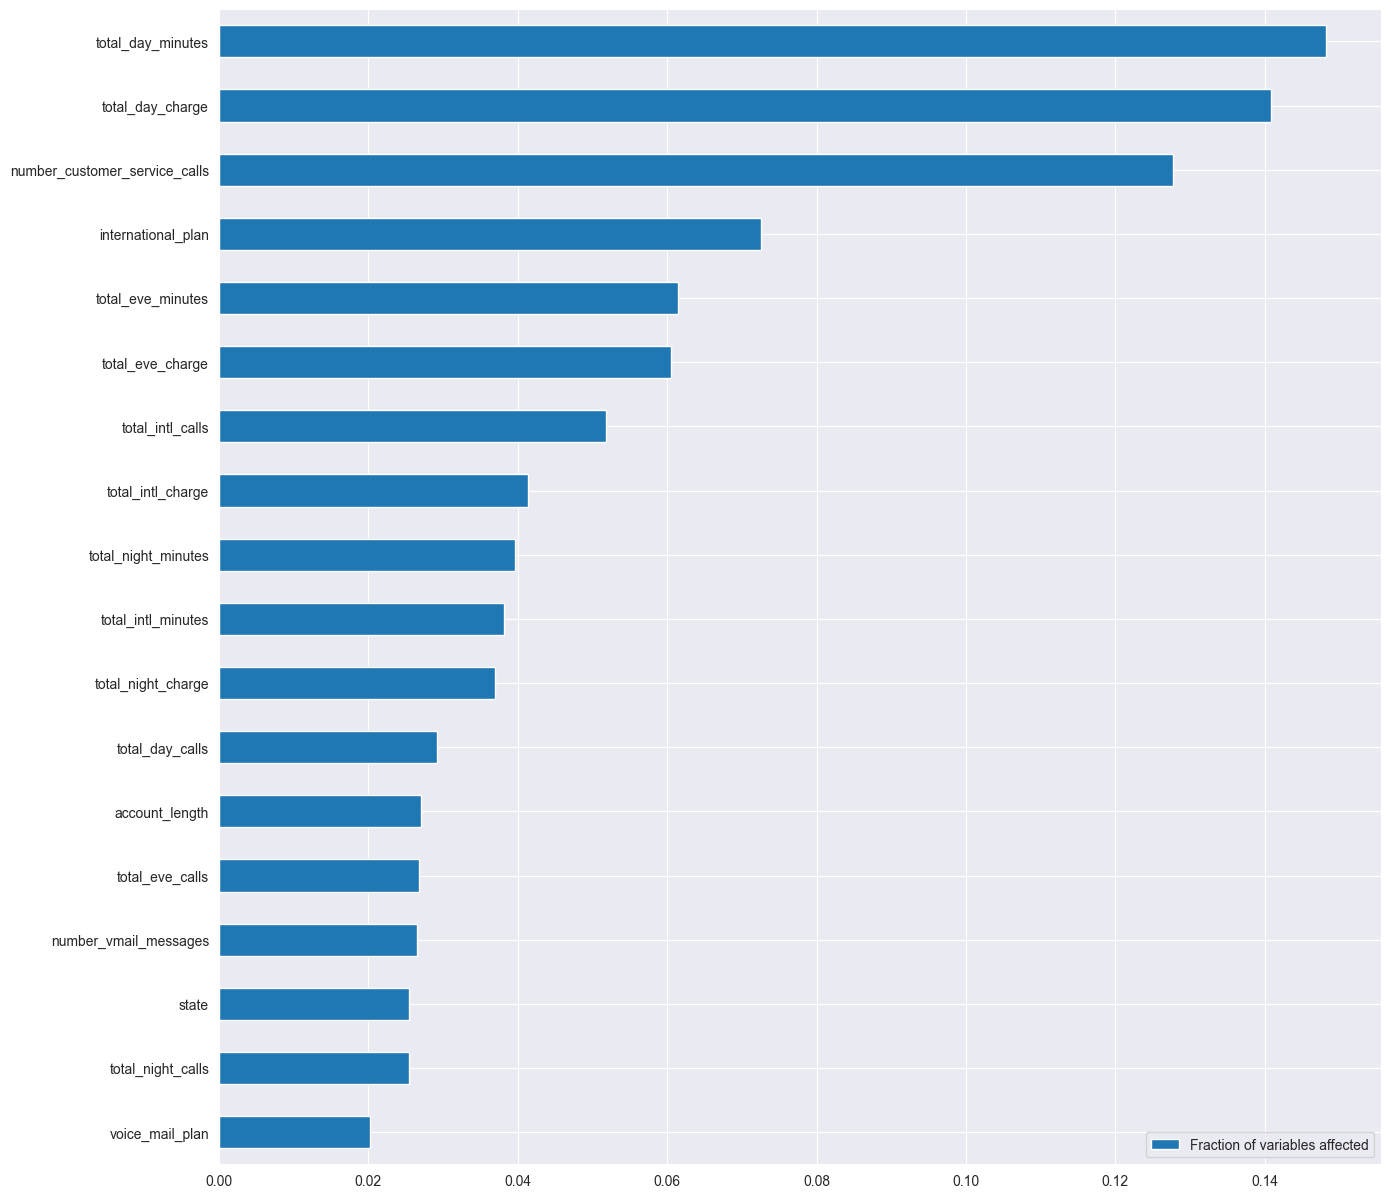

In [119]:
feat_scores=pd.DataFrame({"Fraction of variables affected":rf.feature_importances_},index=x.columns)
feat_scores.sort_values(by='Fraction of variables affected',inplace=True)
feat_scores.plot(kind='barh',figsize=(15,15))


terlihat bahwa total day minute adalah fitur yang paling berpengaruh

**sekarang kita akan menggunakan regresi logistik**

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

**disini kita menggunakan scalling agar data menjadi lebih mudah untuk kovergen(mencapai hasil optimal) lebih cepat dan tidak perlu iterasi banyak**

In [8]:
scaler=StandardScaler()
x_trainScaled=scaler.fit_transform(x_train)
x_testScaled=scaler.transform(x_test)

In [9]:
model_lr=LogisticRegression(class_weight="balanced")
model_lr.fit(x_trainScaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


**support mengitung nilai actual dari true positif dan false negatif, sedangkan presicion akan mengitung berapa persentase true positif dari banyaknya data yang di cap positif dari true positif + false positif, sedangkan recall akan menghitung persentase true positfi berdasarkan nilai yang benar2 positif dari true poistif + false neagtif**

In [10]:
y_predict=model_lr.predict(x_testScaled)
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           0       0.96      0.77      0.85      1293
           1       0.36      0.80      0.49       207

    accuracy                           0.77      1500
   macro avg       0.66      0.78      0.67      1500
weighted avg       0.88      0.77      0.80      1500



In [20]:
telecom_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   state                          5000 non-null   int64  
 1   account_length                 5000 non-null   int64  
 2   area_code                      5000 non-null   int64  
 3   phone_number                   5000 non-null   int64  
 4   international_plan             5000 non-null   int64  
 5   voice_mail_plan                5000 non-null   int64  
 6   number_vmail_messages          5000 non-null   int64  
 7   total_day_minutes              5000 non-null   float64
 8   total_day_calls                5000 non-null   int64  
 9   total_day_charge               5000 non-null   float64
 10  total_eve_minutes              5000 non-null   float64
 11  total_eve_calls                5000 non-null   int64  
 12  total_eve_charge               5000 non-null   f

**jadi confusion matrix akan menunjukan nilai yang true posistif,false positif, true negatif,false negatif dan hasil ini adalah data yang dipakai di report classification dan jika dihitung akan menghasilkan data yang sama dengan report classification**

In [59]:
print(confusion_matrix(y_test,y_predict))

[[992 301]
 [ 41 166]]


<Axes: >

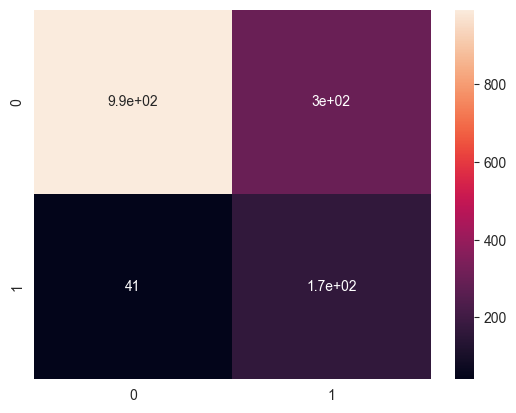

In [60]:
sns.heatmap(confusion_matrix(y_test,y_predict),annot=True)

sekarang kita akan menggunakan svm dan kalibrator

In [11]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import LinearSVC

model_svc=LinearSVC(class_weight="balanced",max_iter=10000)
model_svm=CalibratedClassifierCV(model_svc)
model_svm.fit(x_trainScaled,y_train)

,estimator,LinearSVC(cla...ax_iter=10000)
,method,'sigmoid'
,cv,None
,n_jobs,None
,ensemble,'auto'
,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'


**ini adalah contoh jika tidak memakai calibrator dan langsung svc, hasil racall di nilai 1 sangat besar, yaitu 0.81**

In [ ]:
'''model_svc=LinearSVC(class_weight="balanced",max_iter=10000)
model_svc.fit(x_trainScaled,y_train)'''

In [ ]:
'''y_predict=model_svc.predict(x_testScaled)
print(classification_report(y_test,y_predict))'''

**jadi svm ini bekerja untuk membuat margin atau pemisah antara kelas 0 dan kelas 1,dan dia memakai support vector yaitu nilai yang paling dengan dengan margin dari kedua sisi nilai 0 dan 1, sendangkan calibrator akan berfungsi untuk menerjemahkan nilai svc ini agar nilainya menjadi probabilitas dari 0-1 dengan regresi logistik internal**

In [25]:
y_predict=model_svm.predict(x_testScaled)
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           0       0.89      0.97      0.93      1293
           1       0.59      0.26      0.36       207

    accuracy                           0.87      1500
   macro avg       0.74      0.62      0.65      1500
weighted avg       0.85      0.87      0.85      1500



In [62]:
print(confusion_matrix(y_test,y_predict))

[[1255   38]
 [ 154   53]]


**sekarang kita akan menggunakan randomforest**

ternyata tidak semua model bagus untuk ditambahkan weight class balance, contoh di rf ini jika ditambahkan hyperparameter maka akan berkurang seluruh score nya

In [12]:
from sklearn.ensemble import RandomForestClassifier

model_rf=RandomForestClassifier(random_state=42)
model_rf.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
y_predict=model_rf.predict(x_test)
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1293
           1       0.93      0.76      0.84       207

    accuracy                           0.96      1500
   macro avg       0.95      0.87      0.91      1500
weighted avg       0.96      0.96      0.96      1500



In [70]:
print(confusion_matrix(y_test,y_predict))

[[1282   11]
 [  49  158]]


**sekarang kita akan memakai model k-nearest neighbor**

In [13]:
from sklearn.neighbors import KNeighborsClassifier

model_knn=KNeighborsClassifier()
model_knn.fit(x_trainScaled,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [29]:
y_predict=model_knn.predict(x_testScaled)
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           0       0.91      0.99      0.95      1293
           1       0.81      0.38      0.52       207

    accuracy                           0.90      1500
   macro avg       0.86      0.68      0.73      1500
weighted avg       0.89      0.90      0.89      1500



**sekarang kita akan mencoba naive bayes**

In [14]:
from sklearn.naive_bayes import GaussianNB
model_gnb=GaussianNB()
model_gnb.fit(x_train,y_train)

,priors,None
,var_smoothing,1e-09


In [31]:
y_predict=model_gnb.predict(x_test)
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           0       0.93      0.91      0.92      1293
           1       0.51      0.58      0.54       207

    accuracy                           0.86      1500
   macro avg       0.72      0.74      0.73      1500
weighted avg       0.87      0.86      0.87      1500



In [13]:
confusion_matrix(y_test,y_predict)

array([[1177,  116],
       [  87,  120]])

**sekarang kita akan mennggunakan kurva ROC dan UAC**

In [20]:
model_lr.predict_proba(x_testScaled)

array([[0.67871154, 0.32128846],
       [0.71618192, 0.28381808],
       [0.94926864, 0.05073136],
       ...,
       [0.40502684, 0.59497316],
       [0.00966356, 0.99033644],
       [0.05202382, 0.94797618]], shape=(1500, 2))

agar kita mendapatkan hanya kolom yang churn saja, dan dia ada di kolom 1, maka kita akan mengmabil hanya seluruh baris dan kolom satu saja

In [21]:
model_lr.predict_proba(x_testScaled)[:,1]

array([0.32128846, 0.28381808, 0.05073136, ..., 0.59497316, 0.99033644,
       0.94797618], shape=(1500,))

In [14]:
from sklearn.metrics import roc_curve

In [24]:
fpr1,tpr1,thres1=metrics.roc_curve(y_test,model_lr.predict_proba(x_testScaled)[:,1],pos_label=1)

In [25]:
fpr1

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 7.73395205e-04,
       7.73395205e-04, 1.54679041e-03, 1.54679041e-03, 2.32018561e-03,
       2.32018561e-03, 3.09358082e-03, 3.09358082e-03, 3.86697602e-03,
       3.86697602e-03, 5.41376643e-03, 5.41376643e-03, 6.18716164e-03,
       6.18716164e-03, 6.96055684e-03, 6.96055684e-03, 7.73395205e-03,
       7.73395205e-03, 8.50734725e-03, 8.50734725e-03, 9.28074246e-03,
       9.28074246e-03, 1.08275329e-02, 1.08275329e-02, 1.23743233e-02,
       1.23743233e-02, 1.31477185e-02, 1.31477185e-02, 1.46945089e-02,
       1.46945089e-02, 1.54679041e-02, 1.54679041e-02, 1.70146945e-02,
       1.70146945e-02, 1.77880897e-02, 1.77880897e-02, 2.08816705e-02,
       2.08816705e-02, 2.16550657e-02, 2.16550657e-02, 2.24284609e-02,
       2.24284609e-02, 2.32018561e-02, 2.32018561e-02, 2.70688322e-02,
       2.70688322e-02, 2.78422274e-02, 2.78422274e-02, 3.24825986e-02,
       3.24825986e-02, 3.63495746e-02, 3.63495746e-02, 3.94431555e-02,
      

In [26]:
tpr1

array([0.        , 0.00483092, 0.02415459, 0.02415459, 0.04347826,
       0.04347826, 0.0531401 , 0.0531401 , 0.06763285, 0.06763285,
       0.07246377, 0.07246377, 0.07729469, 0.07729469, 0.08695652,
       0.08695652, 0.10628019, 0.10628019, 0.11594203, 0.11594203,
       0.12560386, 0.12560386, 0.1352657 , 0.1352657 , 0.14492754,
       0.14492754, 0.15458937, 0.15458937, 0.16425121, 0.16425121,
       0.17874396, 0.17874396, 0.18357488, 0.18357488, 0.19323671,
       0.19323671, 0.19806763, 0.19806763, 0.21256039, 0.21256039,
       0.2173913 , 0.2173913 , 0.23188406, 0.23188406, 0.24154589,
       0.24154589, 0.24637681, 0.24637681, 0.25120773, 0.25120773,
       0.26086957, 0.26086957, 0.26570048, 0.26570048, 0.2705314 ,
       0.2705314 , 0.28502415, 0.28502415, 0.29468599, 0.29468599,
       0.29951691, 0.29951691, 0.30434783, 0.30434783, 0.30917874,
       0.30917874, 0.31884058, 0.31884058, 0.32850242, 0.32850242,
       0.33333333, 0.33333333, 0.33816425, 0.33816425, 0.34299

In [27]:
thres1

array([       inf, 0.9977774 , 0.99033644, 0.98738985, 0.98098853,
       0.98028696, 0.97975955, 0.97954437, 0.97654312, 0.97537017,
       0.97534397, 0.97484363, 0.97305359, 0.97139892, 0.96955742,
       0.96838604, 0.95987718, 0.9568958 , 0.95387441, 0.95378267,
       0.95256945, 0.95021168, 0.94797618, 0.94724545, 0.94569904,
       0.94482774, 0.94419015, 0.94336307, 0.93795222, 0.93778729,
       0.93416313, 0.93152869, 0.9308919 , 0.92780807, 0.9267844 ,
       0.92160161, 0.92155727, 0.9214032 , 0.9144269 , 0.90817262,
       0.90684407, 0.90650772, 0.90281606, 0.90161671, 0.90061077,
       0.89999787, 0.89938159, 0.89091369, 0.89034169, 0.89008859,
       0.88634542, 0.88221968, 0.88195558, 0.87710597, 0.87405754,
       0.86858568, 0.86343954, 0.86287878, 0.85815657, 0.85787057,
       0.85551393, 0.85494302, 0.85432131, 0.85425403, 0.85097889,
       0.85097354, 0.84913592, 0.84773268, 0.84612535, 0.84538357,
       0.84501116, 0.8434999 , 0.84173564, 0.8405594 , 0.83934

**sekarang kita akan menghitung semua score untuk kurva roc, pos label digunakan untuk memberi tahu metrics bahwa nilai 1 adalah positif**

In [15]:
fpr1,tpr1,thres1=metrics.roc_curve(y_test,model_lr.predict_proba(x_testScaled)[:,1],pos_label=1)
fpr2,tpr2,thres2=metrics.roc_curve(y_test,model_rf.predict_proba(x_test)[:,1],pos_label=1)
fpr3,tpr3,thres3=metrics.roc_curve(y_test,model_svm.predict_proba(x_testScaled)[:,1],pos_label=1)
fpr4,tpr4,thres4=metrics.roc_curve(y_test,model_gnb.predict_proba(x_test)[:,1],pos_label=1)
fpr5,tpr5,thres5=metrics.roc_curve(y_test,model_knn.predict_proba(x_testScaled)[:,1],pos_label=1)



lalu ini untuk score auc

In [16]:
auc_score1=metrics.roc_auc_score(y_test,model_lr.predict_proba(x_testScaled)[:,1])
auc_score2=metrics.roc_auc_score(y_test,model_rf.predict_proba(x_test)[:,1])
auc_score3=metrics.roc_auc_score(y_test,model_svm.predict_proba(x_testScaled)[:,1])
auc_score4=metrics.roc_auc_score(y_test,model_gnb.predict_proba(x_test)[:,1])
auc_score5=metrics.roc_auc_score(y_test,model_knn.predict_proba(x_testScaled)[:,1])

print("score lr:",auc_score1)
print("score rf:",auc_score2)
print("score svm:",auc_score3)
print("score gnb:",auc_score4)
print("score knn:",auc_score5)

score lr: 0.8338134361537974
score rf: 0.9165069437439052
score svm: 0.83327542209818
score gnb: 0.8523599762377125
score knn: 0.8316894014967252


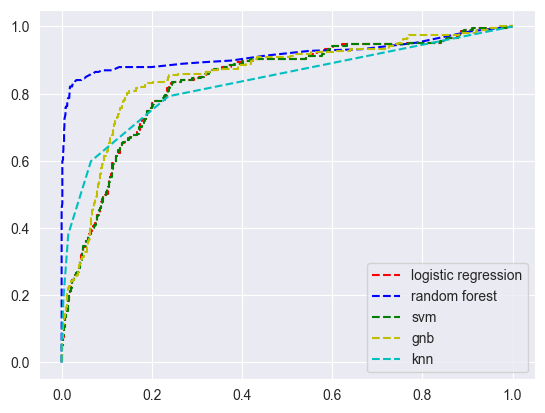

In [23]:
plt.plot(fpr1,tpr1,label='logistic regression',linestyle="--",color='r')
plt.plot(fpr2,tpr2,label='random forest',linestyle="--",color='b')
plt.plot(fpr3,tpr3,label='svm',linestyle="--",color='g')
plt.plot(fpr4,tpr4,label='gnb',linestyle="--",color='y')
plt.plot(fpr5,tpr5,label='knn',linestyle="--",color='c')
plt.legend()


In [17]:
thres1

array([       inf, 0.9977774 , 0.99033644, 0.98738985, 0.98098853,
       0.98028696, 0.97975955, 0.97954437, 0.97654312, 0.97537017,
       0.97534397, 0.97484363, 0.97305359, 0.97139892, 0.96955742,
       0.96838604, 0.95987718, 0.9568958 , 0.95387441, 0.95378267,
       0.95256945, 0.95021168, 0.94797618, 0.94724545, 0.94569904,
       0.94482774, 0.94419015, 0.94336307, 0.93795222, 0.93778729,
       0.93416313, 0.93152869, 0.9308919 , 0.92780807, 0.9267844 ,
       0.92160161, 0.92155727, 0.9214032 , 0.9144269 , 0.90817262,
       0.90684407, 0.90650772, 0.90281606, 0.90161671, 0.90061077,
       0.89999787, 0.89938159, 0.89091369, 0.89034169, 0.89008859,
       0.88634542, 0.88221968, 0.88195558, 0.87710597, 0.87405754,
       0.86858568, 0.86343954, 0.86287878, 0.85815657, 0.85787057,
       0.85551393, 0.85494302, 0.85432131, 0.85425403, 0.85097889,
       0.85097354, 0.84913592, 0.84773268, 0.84612535, 0.84538357,
       0.84501116, 0.8434999 , 0.84173564, 0.8405594 , 0.83934